<a href="https://colab.research.google.com/github/XTMay/ML_DL/blob/main/RNN/Recurrent_Neural_Network_(RNN)_Tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Recurrent Neural Network (RNN) Tutorial

In order to understand Recurrent Neural Networks, let's review the working principle of a feedforward network. Briefly, we can say that a structure that produces output by applying a number of mathematical operations to the information coming to the neurons on the layers.

The information received in the feedforward working structure is only processed forward. In this structure, roughly, an output value is obtained by passing the input data through the network. An error is obtained by comparing the obtained output value with the correct values. The weight values on the network are changed depending on the error and in this way, a model that can output the most accurate result is created.

![](https://pyimagesearch.com/wp-content/uploads/2016/08/simple_neural_network_header.jpg)

In the training of a Feedforward network, the error should be sufficiently reduced. Thus, a structure that will output appropriate to the inpute is created by regenerating the weights going to the neurons.

For example, consider a feedforward network trained to categorize objects on a photo. The given photo can be used for both training and testing, even in a random order. It does not have to be connected with the previous or next photograph. In other words, there is no concept depending on time or order, the only input that it is interested in is the current example.

![](https://miro.medium.com/proxy/1*6xj691fPWf3S-mWUCbxSJg.jpeg)

In recurrent structures, the result is drawn not only by the current inputa but also from other inputs. As can be seen in the figure, besides the input data at time t in RNN, the hidden layer results from the moment t-1 are the input of the hidden layer at the moment t. The decision made for the input at t-1 affects the decision to be made at time t. In other words, inputs in these networks produce output by combining current and previous information.

Recurrent structures are separated from feedforward structures because they use their output as input in the next process. We can say that recurrent networks have a memory. The reason for adding memory to a network is that the input set coming in a certain order has a meaning for the output. Feedforward networks are not sufficient for such data sets.

At this point, RNNs come into play. Recurrent networks are used to understand the structure of the data that comes in a certain order, such as text, speech, various sensors based on time or statistical data.

![](https://files.knime.com/sites/default/files/fig_1_3.png)

As seen in the diagram, the result from the hidden layer in the process loop of RNN both produces output and is written to the content units. In this way, each new input is processed with content units produced by processing previous inputs. If there is a correlation between the data memorized at different times, this is called “long term” addiction. RNN is a network that can calculate the relationship between these long-term dependencies.

In the behavior, speech and thoughts of people, the information that was previously in memory, like this structure, is processed in a hidden layer by looping with new data. The mathematical formula used in this process is as follows.

<img src="https://i.stack.imgur.com/WPRfd.png" width="300"/>

ht is the result of the hidden layer at t. The xt input is multiplied by the W weight. Then at time t-1, h (t-1) value kept in content unit is multiplied by U weight and summed with Wxt. W and U values are the weights between the input and the layer. Here, the weight matrix takes values according to which of the previous and current data has more or less effect on the result. The error resulting from these operations is calculated and new weight values are rearranged with backpropagation. The backprop process continues until the error is sufficiently minimized. Sum of Wxt + Uh (t-1) is put into activation function like sigmoid, tanh. Thus, very large or very small values are placed in a logical range. In this way, non-linearity is also provided.

## An Example Recurrent Neural Network
Let's assume that a cook makes 3 different dishes in order. If she made pizza on the 1st day, sushi on the 2nd day is making waffles on the 3rd day. If we need to guess what to do next day, first we need to understand what kind of problem we are facing and use a method suitable for this problem. The method to be applied here is the recurrent neural network method, since the food comes in a sequence, that is, the meal made the day before will have an effect on the next day. In this way, even if there is no new information with the information we have, we can even guess the meal to be made in the next few weeks.

![](https://elham-khanche.github.io/blog/assets/img/RNN/Slide4.png)

## Backpropagation Trough Time(BPTT)
We can say that the purpose of recurrent networks is to classify sequential inputs correctly. We use the error's backprop and gradient descent to do these operations. Backprop is done in feedforward networks by distributing the error in the probe output to the weights of the backward error. By using this derivative, the learning coefficient is arranged in a gradient descent and weights are arranged to reduce the error.

The method used for RNN is the backprop application for all of a series of time sequential calculations known as BPTT. Artificial networks use a number of functions nested as f (h (g (x))). When a time-dependent variable is added here, the derivative operation can be resolved with the chain rule.

![](https://miro.medium.com/max/936/1*5hp-_tV2gQe80WJSJz9d6w.png)

The working logic of the above RNN is explained. In the figure above, a recurrent network structure with 5 inputs is shown. E denotes the error that occurs here. For example, in the process we do while performing backpropagation for E3, the derivative is used according to the weight of w. To solve this derivative, we use the chain rule and the product of several derivatives.

## Truncated BPTT
Truncated BPTT, on the other hand, approaches BPTT since BPTT will be very costly for forward and backward transactions for a long row of data. The downside to this is that the gradient cut is calculated, so the network cannot learn “long term” dependencies as well as full BPTT.

## Vanishing/Exploding Gradient
Gradient is a value that allows us to adjust all weights. However, in long interconnected networks, the effect of the error decreases considerably and the gradient may start to disappear. This makes it impossible to find the right result. Since all layers and time-dependent steps are interconnected, their derivatives are at risk of extinction or flying, i.e. excessive rise.

![](https://miro.medium.com/max/728/1*TIAsX_WBxLDF_S2jFpnOJw.png)

Gradient exploding, that is, excessive growth, will cause the network to produce huge values and will remove it from the correct result. Putting a threshold for this is cutting simple gradients with high value is one of the simple and effective ways. It is a much more difficult problem for the gradients to disappear with excessive size. It is not clear where and when should be stopped.

Fortunately, there are several solutions to solve this problem. Selecting appropriate initial values for W will reduce the extinction effect. Another solution is to use ReLU instead of sigmoid and tanh activation functions. The derivative of the ReLU function is 0 or 1. For this reason, such a problem will not be included. Another method is the LSTM method designed to solve this problem.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')


# Loading & Visualization the Dataset

In [ ]:
dataset = pd.read_csv("/content/drive/MyDrive/AI_Lecture/ML_DL/Dataset/RNN/avocado.csv")[0:5000]
dataset.head()

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    5000 non-null   int64  
 1   Date          5000 non-null   object 
 2   AveragePrice  5000 non-null   float64
 3   Total Volume  5000 non-null   float64
 4   4046          5000 non-null   float64
 5   4225          5000 non-null   float64
 6   4770          5000 non-null   float64
 7   Total Bags    5000 non-null   float64
 8   Small Bags    5000 non-null   float64
 9   Large Bags    5000 non-null   float64
 10  XLarge Bags   5000 non-null   float64
 11  type          5000 non-null   object 
 12  year          5000 non-null   int64  
 13  region        5000 non-null   object 
dtypes: float64(9), int64(2), object(3)
memory usage: 547.0+ KB


In [ ]:
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,5000.0,2.546480e+01,1.502386e+01,0.00,12.0000,25.000,38.0000,51.00
AveragePrice,5000.0,1.096252e+00,2.143175e-01,0.49,0.9700,1.080,1.2200,2.07
Total Volume,5000.0,1.243722e+06,3.386675e+06,35852.68,186710.9125,374781.395,930839.1675,44655461.51
4046,5000.0,4.362624e+05,1.389560e+06,106.84,22077.5800,93011.500,275819.3850,18933038.04
4225,5000.0,5.016715e+05,1.376724e+06,1614.16,53096.4450,142737.850,393301.1150,18956479.74
4770,5000.0,4.297084e+04,1.222404e+05,0.00,757.9000,8510.715,25937.9375,1614282.73
Total Bags,5000.0,2.628170e+05,6.181538e+05,3047.17,49881.7725,81232.270,201430.4500,6743614.96
Small Bags,5000.0,2.154472e+05,5.191404e+05,1119.18,38318.3800,64820.225,146639.1550,5893641.72
Large Bags,5000.0,4.439724e+04,1.118379e+05,0.00,1143.2175,9084.905,41536.9100,1371440.28
XLarge Bags,5000.0,2.972560e+03,9.936628e+03,0.00,0.0000,15.400,1310.8350,199305.12


In [ ]:
train = dataset.loc[:,["AveragePrice"]].values
train

array([[1.33],
       [1.35],
       [0.93],
       ...,
       [1.89],
       [1.94],
       [2.07]])

In [ ]:
val = dataset.loc[:,["AveragePrice"]].values
val

In [ ]:
test = dataset.loc[:,["AveragePrice"]].values
test

In [ ]:
# Feature Scaling
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range = (0, 1))
train_scaled = scaler.fit_transform(train)
train_scaled

array([[0.53164557],
       [0.5443038 ],
       [0.27848101],
       ...,
       [0.88607595],
       [0.91772152],
       [1.        ]])

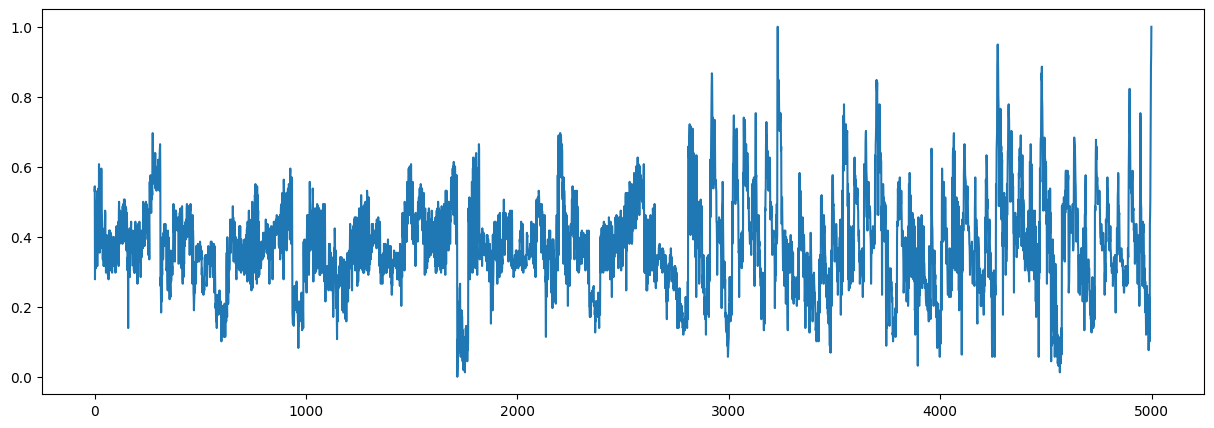

In [ ]:
plt.figure(figsize=(15, 5));
plt.plot(train_scaled);
plt.show()

In [ ]:
dataset.shape[0]

5000

In [ ]:
# Creating a data structure with 250 timesteps and 1 output
X_train = []
y_train = []
timesteps = 250

for i in range(timesteps,dataset.shape[0]):
    X_train.append(train_scaled[i-timesteps:i,0])
    y_train.append(train_scaled[i,0])

print("X_train length: ", len(X_train))
print("y_train length: ", len(y_train))

X_train length:  4750
y_train length:  4750


In [ ]:
X_train, y_train = np.array(X_train), np.array(y_train)

In [ ]:
# Reshaping
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
len(X_train[0])

250

In [ ]:
y_train[0:10]

array([0.43037975, 0.39240506, 0.46835443, 0.44936709, 0.34810127,
       0.46202532, 0.43037975, 0.46835443, 0.38607595, 0.33544304])

In [ ]:
X_train.shape

(4750, 250, 1)

# Create RNN Model

In [ ]:
# Importing the Keras libraries and packages
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import SimpleRNN
from keras.layers import Dropout

regressor = Sequential() # initialising the RNN

# adding the first RNN layer and some Droupout regularisation
regressor.add(SimpleRNN(units=50, activation="tanh", return_sequences=True, input_shape=(X_train.shape[1],1)))
# (X_train.shape[1],1) => output: (250,1)
regressor.add(Dropout(0.2)) # TODO

# adding the second RNN layer and some Droupout regularisation
regressor.add(SimpleRNN(units=50, activation="tanh", return_sequences=True))
regressor.add(Dropout(0.2))

# adding the third RNN layer and some Droupout regularisation
regressor.add(SimpleRNN(units=50, activation="tanh", return_sequences=True))
regressor.add(Dropout(0.2))

# adding a fourth RNN layer and some Dropout regularisation
regressor.add(SimpleRNN(units=50))
regressor.add(Dropout(0.2))

# adding the output layer
regressor.add(Dense(units = 1))

# Compiling the RNN
regressor.compile(optimizer = 'adam', loss = 'mean_squared_error')

# Fitting the RNN to the Training set
regressor.fit(X_train, y_train, epochs = 20, batch_size = 132)

Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 20s 402ms/step - loss: 0.5176
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 20s 387ms/step - loss: 0.2442
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 20s 394ms/step - loss: 0.1617
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 14s 397ms/step - loss: 0.1200
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 21s 397ms/step - loss: 0.0904
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 20s 401ms/step - loss: 0.0685
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 21s 421ms/step - loss: 0.0582
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 14s 388ms/step - loss: 0.0507
Epoch 9/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 21s 396ms/step - loss: 0.0386
Epoch 10/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 20s 395ms/step - loss: 0.0328
Epoch 11/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 14s 393ms/step - loss: 0.0274
Epoch 12/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 21s 394ms/step - loss: 0.0238
Epoch 13/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 20s 394ms/step - loss: 0.0205
Epoch 14/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 14s 398ms/step - loss: 0.0191
Epoch 15/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 14s 

In [ ]:
dataset_test = pd.read_csv("/content/drive/MyDrive/AI_Lecture/ML_DL/Dataset/RNN/avocado.csv")[5000:10000]
dataset_test.head()

,Unnamed: 0,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
5000,8,2016-10-30,2.20,477937.80,130025.36,285048.20,3399.09,59465.15,57223.44,269.21,1972.50,conventional,2016,SanFrancisco
5001,9,2016-10-23,1.87,411873.66,133676.77,178795.94,4817.03,94583.92,89533.10,2966.65,2084.17,conventional,2016,SanFrancisco
5002,10,2016-10-16,1.99,590535.06,141221.01,362859.22,7787.57,78667.26,74349.15,3259.50,1058.61,conventional,2016,SanFrancisco
5003,11,2016-10-09,1.82,673082.26,163264.54,409307.88,9771.72,90738.12,89663.48,1055.05,19.59,conventional,2016,SanFrancisco
5004,12,2016-10-02,1.52,731993.57,196085.62,421421.20,10626.67,103860.08,101544.87,1167.15,1148.06,conventional,2016,SanFrancisco


In [ ]:
test = dataset_test.loc[:,["AveragePrice"]].values
test

array([[2.2 ],
       [1.87],
       [1.99],
       ...,
       [1.79],
       [2.09],
       [1.72]])

In [ ]:
# Getting the predicted stock price of 2017
dataset_total = pd.concat((dataset['AveragePrice'], dataset_test['AveragePrice']), axis = 0)
inputs = dataset_total[len(dataset_total) - len(dataset_test) - timesteps:].values.reshape(-1,1)
inputs = scaler.transform(inputs)  # min max scaler
inputs

array([[0.50632911],
       [0.49367089],
       [0.51898734],
       ...,
       [0.82278481],
       [1.01265823],
       [0.77848101]])

# Predict

Predict _ price? actual price

- MSE